In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spotify-songs/dataset.csv


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance

In [26]:
data = pd.read_csv('/kaggle/input/spotify-songs/dataset.csv')

In [27]:
data

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


Рассмотрим все столбцы:
1. **Unnamed** - порядковый номер песни
2. **track_id** - уникальный идентификатор песни, набор символов
3. **artists** - исполнители, если их несколько, перечислены через ";"
4. **album_name** - название альбома
5. **track_name** - название композиции
6. **popularity** - значение популярности трека, от 1 до 100, одно из главных значений для предсказания
7. **duration_ms** - длительность трека в милисекундах
8. **explicit** - наличие/отсутствие нецензурной лексики
9. **danceability** - показатель танцевальности трека, от 0 до 1
10. **energy** - уровень энергии трека, от 0 до 1
11. **key** - тональность трека, значения от 0 до 11
12. **loudness** - уровень громкости трека, целое число с десятичной дробью
13. **mode** - лад (мажор или минор), 0 или 1
14. **speechiness** - оценка доли речи в треке, от 0 до 1
15. **acousticness** - степень акустичности трека, от 0 до 1
16. **instrumentalness** - показатель инструментальности композиции, от 0 до 1
17. **liveness** - параметр, отражающий вероятность того, что трек исполнен вживую, от 0 до 1
18. **valence** - отражает настроение трека, от 0 до 1
19. **tempo** - скорость трека (BPM)
20. **time_signature** - размер тактов композиции, от 0 до 5
21. **track_genre** - жанр трека

# Нормализация данных

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [29]:
total_popularity_count = data['popularity'].count()
popularity_zero_count = data[data['popularity'] == 0]['popularity'].count()
print(f"Общее количество записей в 'popularity': {total_popularity_count}")
print(f"Количество записей, где 'popularity' = 0: {popularity_zero_count}")

Общее количество записей в 'popularity': 114000
Количество записей, где 'popularity' = 0: 16020


Мне кажется, что записи с нулевой популярностью негативно скажутся на обучении модели, поэтому я их удалю

In [30]:
data = data[data['popularity'] != 0]

In [31]:
data.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Удаляем столбцы Unnamed, track_id и значения с пропусками

In [32]:
data = (data
        .drop(data.columns[0], axis=1)
        .drop(data.columns[1], axis=1)
        .dropna())
data

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


Столбец 'explicit' преобразуем в целочисленный тип (True - 1, False - 0)

In [33]:
data['explicit'] = data['explicit'].astype(int)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97980 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           97980 non-null  object 
 1   album_name        97980 non-null  object 
 2   track_name        97980 non-null  object 
 3   popularity        97980 non-null  int64  
 4   duration_ms       97980 non-null  int64  
 5   explicit          97980 non-null  int64  
 6   danceability      97980 non-null  float64
 7   energy            97980 non-null  float64
 8   key               97980 non-null  int64  
 9   loudness          97980 non-null  float64
 10  mode              97980 non-null  int64  
 11  speechiness       97980 non-null  float64
 12  acousticness      97980 non-null  float64
 13  instrumentalness  97980 non-null  float64
 14  liveness          97980 non-null  float64
 15  valence           97980 non-null  float64
 16  tempo             97980 non-null  float64
 1

Построим матрицу корреляции для столбцов с числовыми значениями, чтобы пронаблюдать зависимости

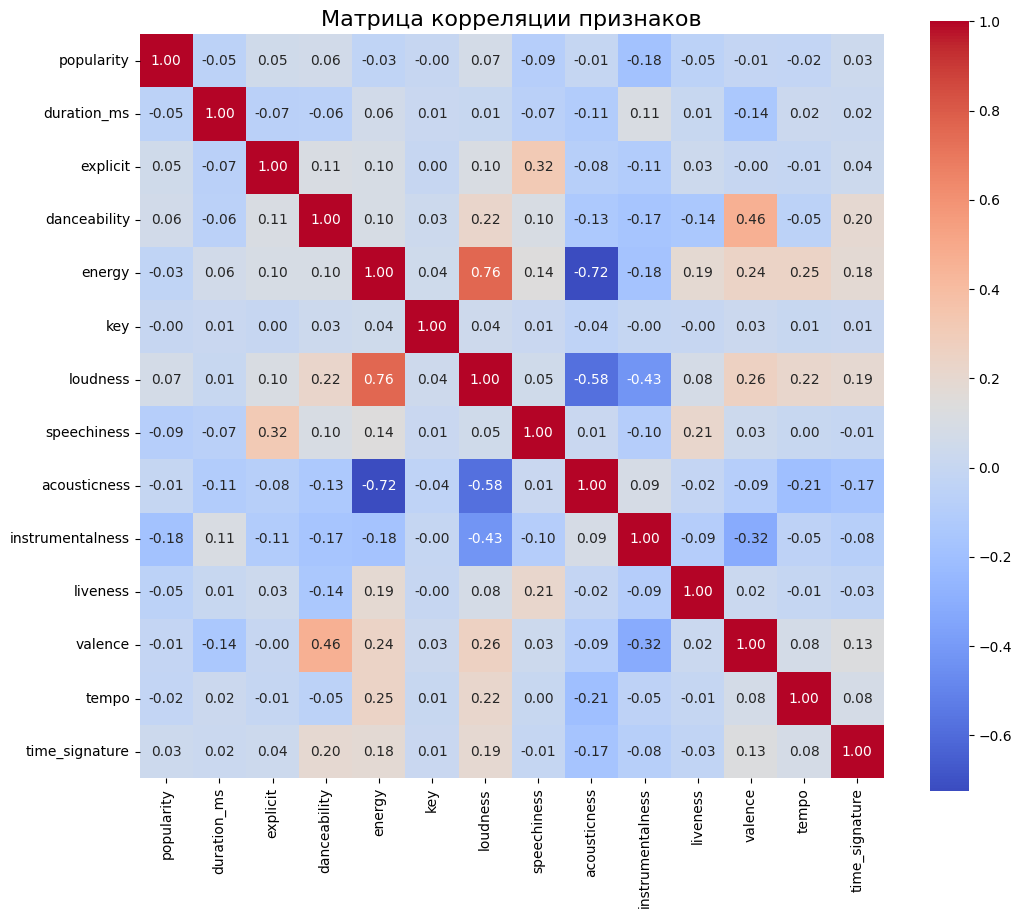

In [34]:
correlation_matrix = data.loc[:, [
    'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 
    'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
    'liveness', 'valence', 'tempo', 'time_signature'
]].corr()

# Настраиваем размер фигуры
plt.figure(figsize=(12, 10))

# Создаём тепловую карту с помощью seaborn
sns.heatmap(
    correlation_matrix, 
    annot=True,  # Показать значения корреляции на тепловой карте
    fmt=".2f",   # Формат значений
    cmap="coolwarm",  # Цветовая палитра
    cbar=True,  # Отображение цветовой шкалы
    square=True # Квадратная форма ячеек
)

plt.title("Матрица корреляции признаков", fontsize=16)
plt.show()

**energy** и **loudness**: показатель 0.76 говорит о сильной корреляции между энергичностью и громкостью песни

Также прослеживается корреляция между признаками **danceability** и **valence**: 0.46. Танцевальные песни более эмоциональны

Неожиданная корреляция между признаками **speechiness** и **explicit** (0.32) свидетельствует о наличии материалов для взрослых в композициях с уклоном на текст.

**valence** и **loudness**: корреляция 0.26 - эмоциональная музыка более громкая

В то же время большая отрицательная корреляция признаков как **acousticness** и **energy** (-0.72) указывает на то, что акустическая музыка, как правило, неэнергична

**acousticness** и **loudness** и **instrumentalness** и **loudness**: отрицательная корреляция (-0.58) и (-0.43) свидетельствует о том, что акустические и инструментальные песни чаще всего в тихом исполнении

**instrumentalness** и **valence** - признаки имеют отрицательную корреляцию (-0.32) - инструментальная музыка менее эмоциональна.
 
Остальные признаки, включая popularity, имеют низкие корреляции. Это говорит о том, что популярность песни определяется множеством факторов, которые не отражены в текущих признаках.

# **Гипотезы о факторах, влияющих на популярность песен:**
1. **track_genre**: попсовые жарны имеют более широкую аудиторию, чем нишевые
2. **energy**: энергичная музыка чаще нравятся широкой аудитории и популиризируется на различного рода тусовках, вечеринках и прочих мероприятиях
3. **danceability**: танцевальная музыка популярна,так как также часто используются в клубах и т.д.
4. **loudness**: громкие и насыщенные звучанием песни могут привлекать больше слушателей
5. **tempo**: песни с быстрым темпом 120-150bpm более популярны среди массовой аудитории.
6. **duration_ms**: популярные песни не должны длиться слишком долго, чтобы среднестатичстический пользователь не успел утомиться.
7. **explicit**: песни без отметки "для взрослых" более популярны, так как охватывают более широкую аудиторию, включая молодежь и детей,а также их допустимо прослушивать в общественных местах
8. **artists**: песни, созданные в коллаборации артистов популярны, так как охватывают большую аудиторию фанатов.

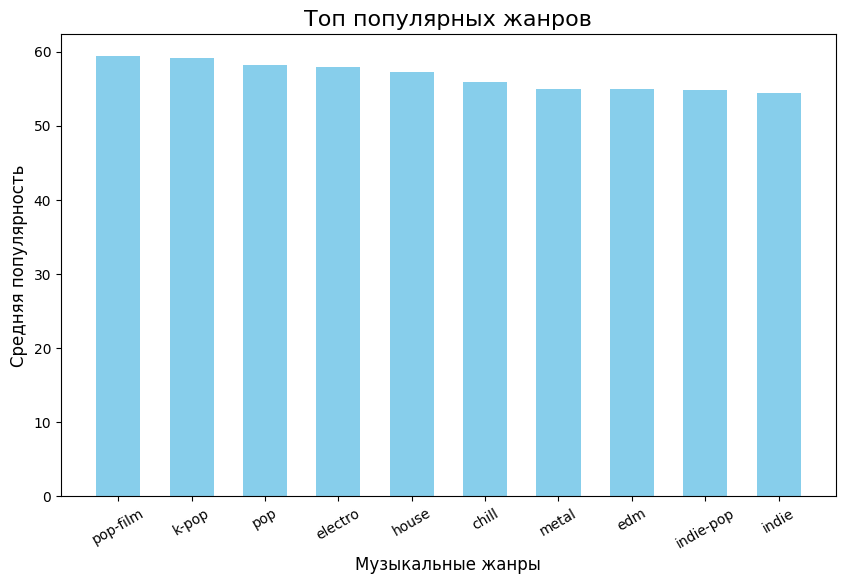

In [35]:
genre_popularity = data.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

top_genres = genre_popularity.head(10)

genres = top_genres.index
popularity = top_genres.values

plt.figure(figsize=(10, 6))
plt.bar(genres, popularity, color='skyblue', width=0.6)

plt.title('Топ популярных жанров', fontsize=16)
plt.xlabel('Музыкальные жанры', fontsize=12)
plt.ylabel('Средняя популярность', fontsize=12)
plt.xticks(rotation=30, fontsize=10)
plt.yticks(fontsize=10)

plt.show()

Чтобы убедиться в достоверности гипотезы №1, построим график для менее популярных жанров

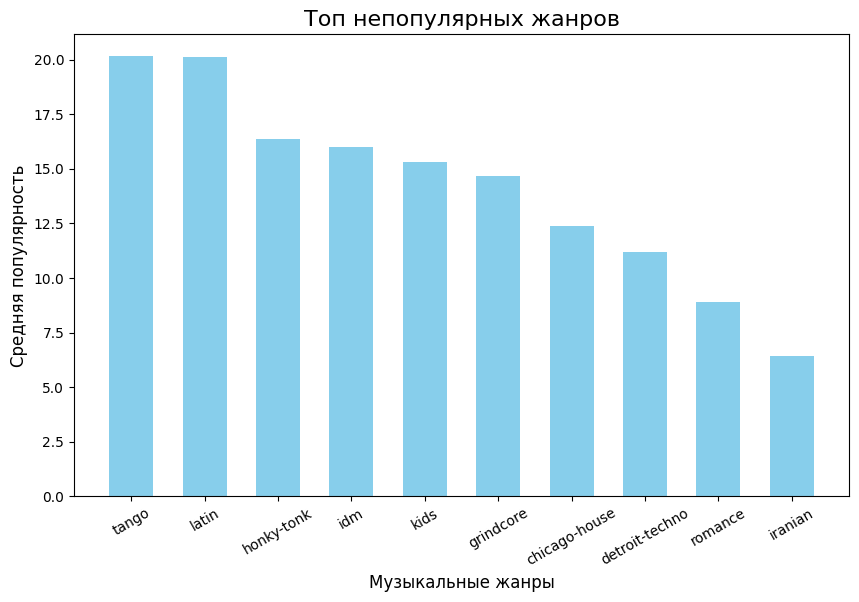

In [36]:
genre_popularity = data.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

top_genres = genre_popularity.tail(10)

genres = top_genres.index
popularity = top_genres.values

plt.figure(figsize=(10, 6))
plt.bar(genres, popularity, color='skyblue', width=0.6)

plt.title('Топ непопулярных жанров', fontsize=16)
plt.xlabel('Музыкальные жанры', fontsize=12)
plt.ylabel('Средняя популярность', fontsize=12)
plt.xticks(rotation=30, fontsize=10)
plt.yticks(fontsize=10)

plt.show()

2 этих графика **подтверждают** гипотезу №1 о связи определенных жанров с популярностью музыки, поскольку мы можем выделить наиболее и наименее популярные из них, со значительным отрывом. Причем наиболее популярными оказались жанры поп музыки

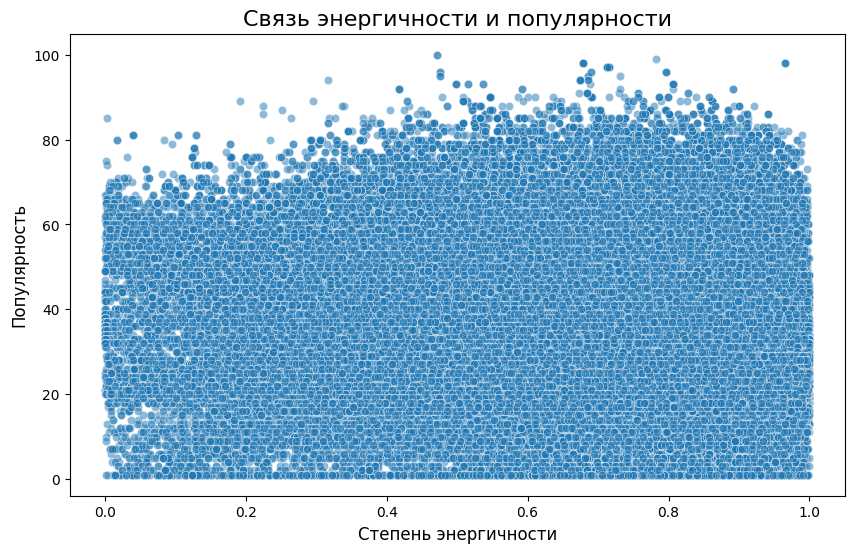

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='energy', y='popularity', data=data, alpha=0.5)
plt.title("Связь энергичности и популярности", fontsize=16)
plt.xlabel("Степень энергичности", fontsize=12)
plt.ylabel("Популярность", fontsize=12)
plt.show()

Гипотеза №2 **не подтвердилась**, степень энергичности особо не влияет на популярность музыки

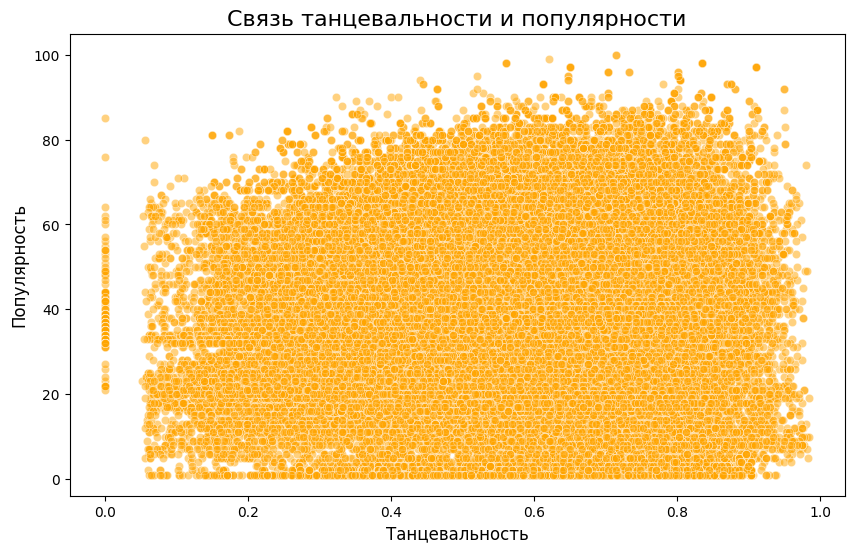

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='danceability', y='popularity', data=data, alpha=0.5, color='orange')
plt.title("Связь танцевальности и популярности", fontsize=16)
plt.xlabel("Танцевальность", fontsize=12)
plt.ylabel("Популярность", fontsize=12)
plt.show()

Гипотеза №3 **не подтвердилась**, степень танцевальности особо не влияет на популярность музыки

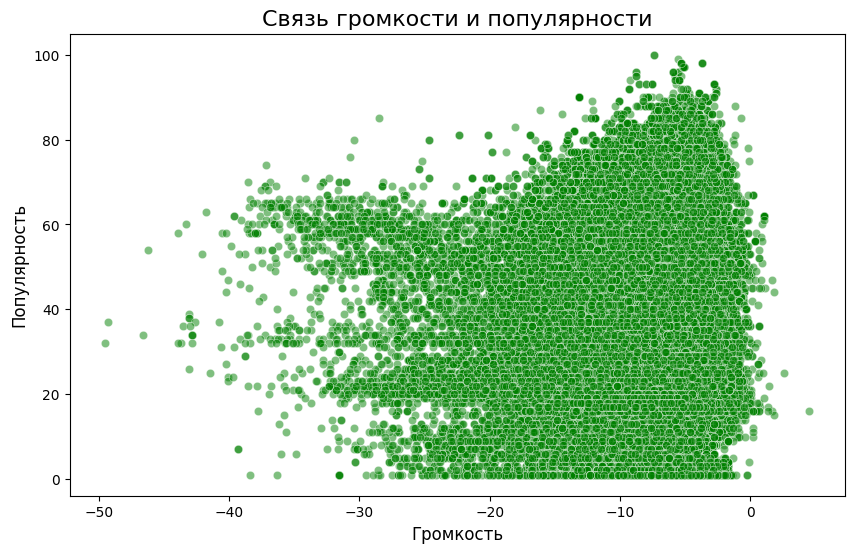

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='loudness', y='popularity', data=data, alpha=0.5, color='green')
plt.title("Связь громкости и популярности", fontsize=16)
plt.xlabel("Громкость", fontsize=12)
plt.ylabel("Популярность", fontsize=12)
plt.show()

Гипотеза №4 **подтвердилась**. Судя по графику, большинство композиций находятся в диапазоне от -20 до 0 Дб, а наиболее популярные встречаются лишь в диапазоне от -10 до 0 Дб.

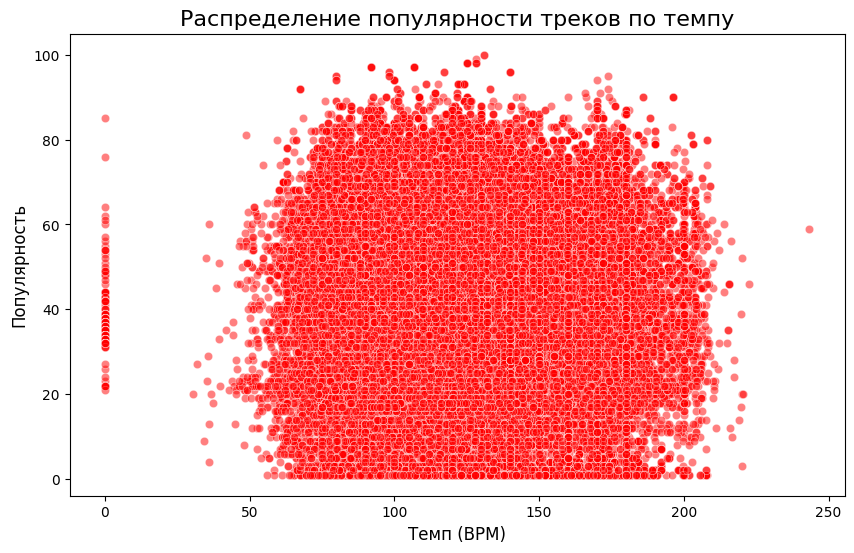

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tempo', y='popularity', data=data, alpha=0.5, color='red')
plt.title("Распределение популярности треков по темпу", fontsize=16)
plt.xlabel("Темп (BPM)", fontsize=12)
plt.ylabel("Популярность", fontsize=12)
plt.show()

Гипотеза №5 **не подтвердилась** - скорость музыки не влияет на популярность

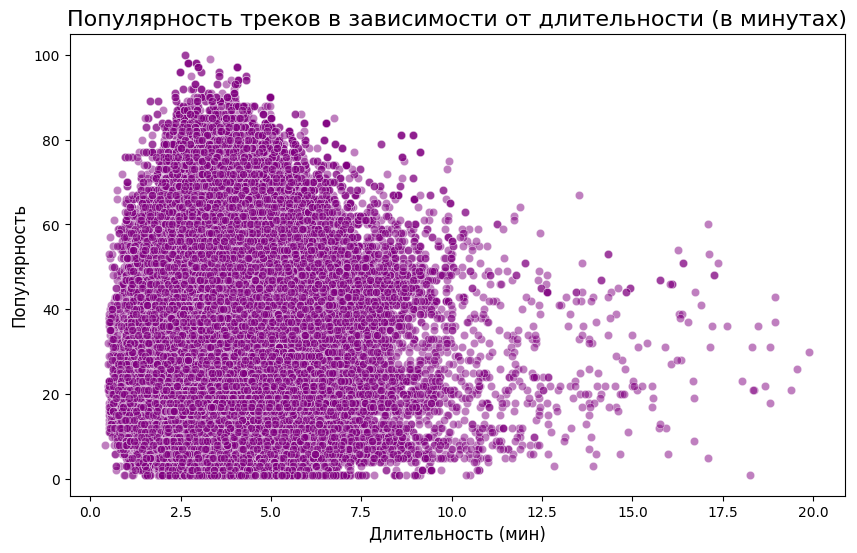

In [41]:
data['duration_min'] = data['duration_ms'] / 60000

# выводим треки только до 20 минут
filtered_data = data[data['duration_min'] <= 20]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=filtered_data, alpha=0.5, color="purple")
plt.title("Популярность треков в зависимости от длительности (в минутах)", fontsize=16)
plt.xlabel("Длительность (мин)", fontsize=12)
plt.ylabel("Популярность", fontsize=12)
plt.show()

Гипотеза №6 **подтвердилась**, наиболее популярные песни длятся не дольше 5 
минут

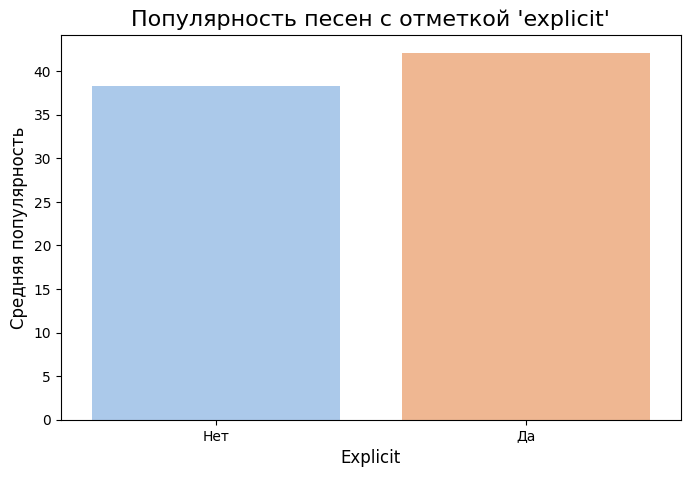

In [42]:
explicit_popularity = data.groupby('explicit')['popularity'].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=explicit_popularity.index, y=explicit_popularity.values, palette='pastel')
plt.title("Популярность песен с отметкой 'explicit'", fontsize=16)
plt.xlabel("Explicit", fontsize=12)
plt.ylabel("Средняя популярность", fontsize=12)
plt.xticks([0, 1], ['Нет', 'Да'])
plt.show()

Гипотеза №7 **не подтвердилась**, песни с отметкой Explicit и без +- одинаково популярны

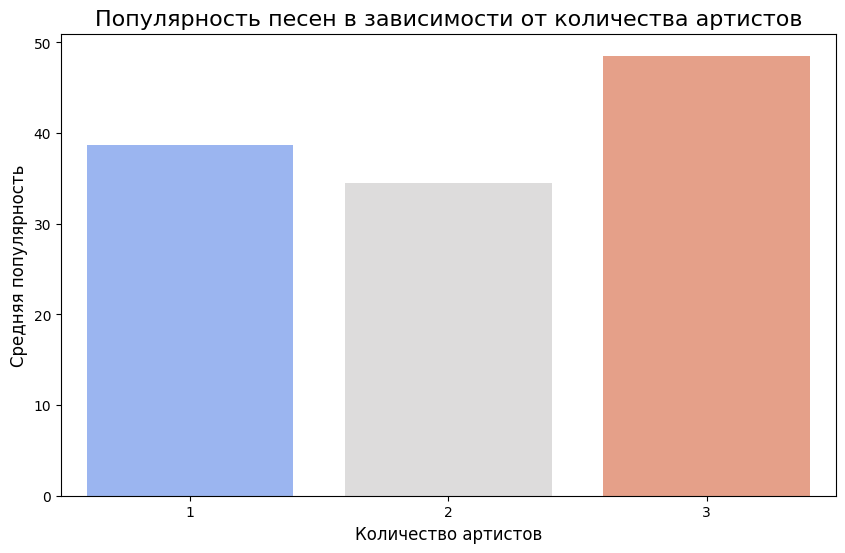

In [43]:
data['num_artists'] = data['artists'].apply(lambda x: len(str(x).split(',')))
collab_popularity = data.groupby('num_artists')['popularity'].mean()
plt.figure(figsize=(10, 6))
sns.barplot(x=collab_popularity.index, y=collab_popularity.values, palette='coolwarm')
plt.title("Популярность песен в зависимости от количества артистов", fontsize=16)
plt.xlabel("Количество артистов", fontsize=12)
plt.ylabel("Средняя популярность", fontsize=12)
plt.show()

Гипотеза №8 **подтвердилась**, средняя популярность треков с 3 исполнителями чуть выше, чем с 1 или 2

# **Создание новых признаков**
1. **energy_loudness_prod**: комбинация energy и loudness 
2.  **low_energy_instrumental**: признак выделяет спокойную акустическую музыку, если комопзиция подходит под это описание - 1, иначе 0
3. **loudness_category**: параметр громкости разобьем на 4 категории: <-30Дб; -30Дб..-20Дб; -20Дб..-10Дб; -10Дб..0Дб значения для каждого промежутка соответсвтенно 1, 2, 3, 4.
4. **duration_category**: параметр громкости разобьем на 5 категориq: до 2 минут; 2-5 минут; 5-8 минут; 8-12 минут, значения для каждого промежутка соответсвтенно 1, 2, 3, 4, 5.
5. **artists_quantity**: количество исполнителей

In [44]:
# 1 Признак: взаимодействие энергичности и громкости
data['energy_loudness_prod'] = data['energy'] * data['loudness']

# 2 Признак: треки с акустичностью выше среднего и енергичностью ниже среднего
data['low_energy_instrumental'] = ((data['acousticness'] > data['acousticness'].mean()) & (data['energy'] < data['energy'].mean())).astype(int)

# 3 Признак: делим треки на категории по громкости
bins_loudness = [-float('inf'), -30, -20, -10, 0]
labels_loudness = [1, 2, 3, 4]
data['loudness_category'] = pd.cut(data['loudness'], bins=bins_loudness, labels=labels_loudness).cat.add_categories([0]).fillna(0).astype(int)

# 4 Признак: делим треки на категории по длительности
bins_duration = [0, 2, 5, 8, 12, float('inf')]
labels_duration = [1, 2, 3, 4, 5]
data['duration_category'] = pd.cut(data['duration_min'], bins=bins_duration, labels=labels_duration).cat.add_categories([0]).fillna(0).astype(int)

# 5 Признак: делим треки на категории по кол-ву исполнителей
def count_artists_category(artists):
    if isinstance(artists, str):
        return len(artists.split(","))
data['artists_quantity'] = data['artists'].apply(count_artists_category)

data.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,...,tempo,time_signature,track_genre,duration_min,num_artists,energy_loudness_prod,low_energy_instrumental,loudness_category,duration_category,artists_quantity
0,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,...,87.917,4,acoustic,3.844433,1,-3.109906,0,4,2,1
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,...,77.489,4,acoustic,2.493500,1,-2.861010,1,3,2,1
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,...,76.332,4,acoustic,3.513767,1,-3.494506,0,4,2,1
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,...,181.740,3,acoustic,3.365550,1,-1.103494,1,3,2,1
4,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,...,119.949,4,acoustic,3.314217,1,-4.288683,1,4,2,1


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97980 entries, 0 to 113999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   artists                  97980 non-null  object 
 1   album_name               97980 non-null  object 
 2   track_name               97980 non-null  object 
 3   popularity               97980 non-null  int64  
 4   duration_ms              97980 non-null  int64  
 5   explicit                 97980 non-null  int64  
 6   danceability             97980 non-null  float64
 7   energy                   97980 non-null  float64
 8   key                      97980 non-null  int64  
 9   loudness                 97980 non-null  float64
 10  mode                     97980 non-null  int64  
 11  speechiness              97980 non-null  float64
 12  acousticness             97980 non-null  float64
 13  instrumentalness         97980 non-null  float64
 14  liveness                 9

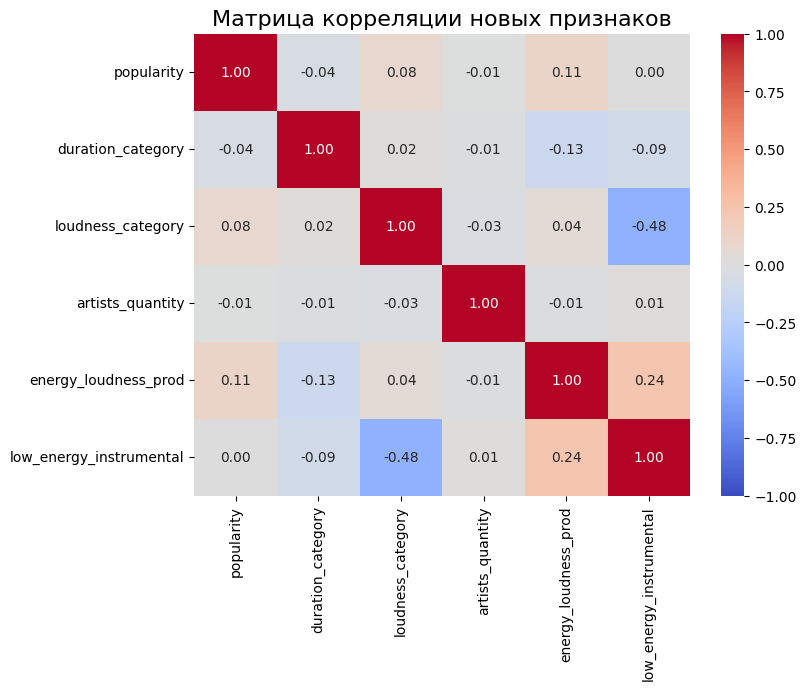

In [46]:
columns_for_corr = ['popularity', 'duration_category', 'loudness_category', 'artists_quantity', 'energy_loudness_prod', 'low_energy_instrumental']

correlation_matrix = data[columns_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Матрица корреляции новых признаков', fontsize=16)
plt.show()

К сожалению, новые признаки слабо коррелируют с целевым

# **Создание базовой модели для выявления наиболее важных признаков**

Закодируем колонки, содержаещие тип object. 

In [47]:
from copy import deepcopy
from sklearn.preprocessing import LabelEncoder

normalized_data = deepcopy(data)
object_cols = normalized_data.select_dtypes(include=['object']).columns
label_encoders = {}

for col in object_cols:
    label_encoder = LabelEncoder()
    normalized_data[col] = label_encoder.fit_transform(normalized_data[col])
    label_encoders[col] = label_encoder  # Сохраняем LabelEncoder для возможного обратного преобразования

In [48]:
normalized_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97980 entries, 0 to 113999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   artists                  97980 non-null  int64  
 1   album_name               97980 non-null  int64  
 2   track_name               97980 non-null  int64  
 3   popularity               97980 non-null  int64  
 4   duration_ms              97980 non-null  int64  
 5   explicit                 97980 non-null  int64  
 6   danceability             97980 non-null  float64
 7   energy                   97980 non-null  float64
 8   key                      97980 non-null  int64  
 9   loudness                 97980 non-null  float64
 10  mode                     97980 non-null  int64  
 11  speechiness              97980 non-null  float64
 12  acousticness             97980 non-null  float64
 13  instrumentalness         97980 non-null  float64
 14  liveness                 9

Разделение данных на обучающую и тестовую выборки

In [49]:
X = normalized_data.drop(columns=['popularity']) 
y = normalized_data['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
import tensorflow as tf
from tensorflow import keras

In [51]:
from tensorflow.keras import Input

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Строим модель
model = keras.Sequential([
    Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

# Компилируем модель
model.compile(optimizer='adam', loss='mean_squared_error')

# Обучаем модель
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Оцениваем модель
loss = model.evaluate(X_test, y_test)

#Прогнозирование на тестовой выборке
y_pred = model.predict(X_test)
# Вычисление метрик
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f'Test Loss: {loss}')
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')

Epoch 1/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 561.7606 - val_loss: 339.2133
Epoch 2/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 328.7509 - val_loss: 329.9557
Epoch 3/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 321.9969 - val_loss: 328.0965
Epoch 4/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 316.0047 - val_loss: 322.6628
Epoch 5/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 311.8100 - val_loss: 316.0916
Epoch 6/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 302.3961 - val_loss: 313.8471
Epoch 7/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 304.2713 - val_loss: 312.5706
Epoch 8/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 299.2661 - val_loss: 311.0472
Epoch 9/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 296.6690 - val_loss: 307.4695
Epoch 10/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 297.5032 - val_loss: 304.9995
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 310.2294
613/613 ━━━━━━━━━━━━━

**Test Loss** - значение функции потерь на тестовых данных
**MSE** -  средняя квадратичная ошибка 
**MAE** - средняя абсолютная ошибка
**RMSE** - корень из средней квадратичной ошибкием

In [52]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'MAPE: {mape}')

MAPE: 1.6027035864157864


**Mape** - метрика, которая измеряет среднюю абсолютную процентную ошибку между предсказанными значениями и истинными

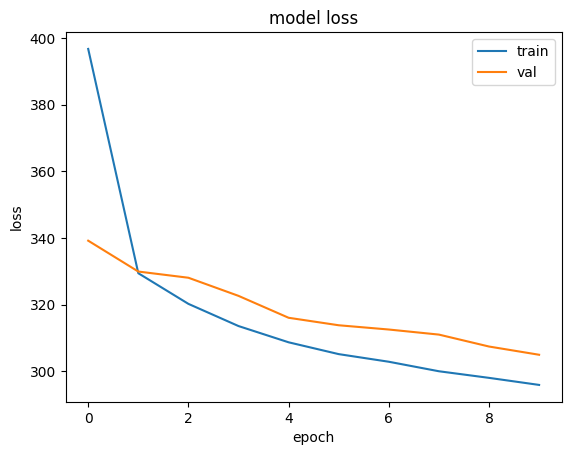

In [53]:
# Изменение потерь на тренировочном датасете
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt. xlabel ('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

Параметры измерения ошибок показали низкое качество предсказаний модели на тестовой выборке. Попробую измерить важность признаков с помощью permutation importance для дальнейшего анализа

# **Важность признаков**

613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━

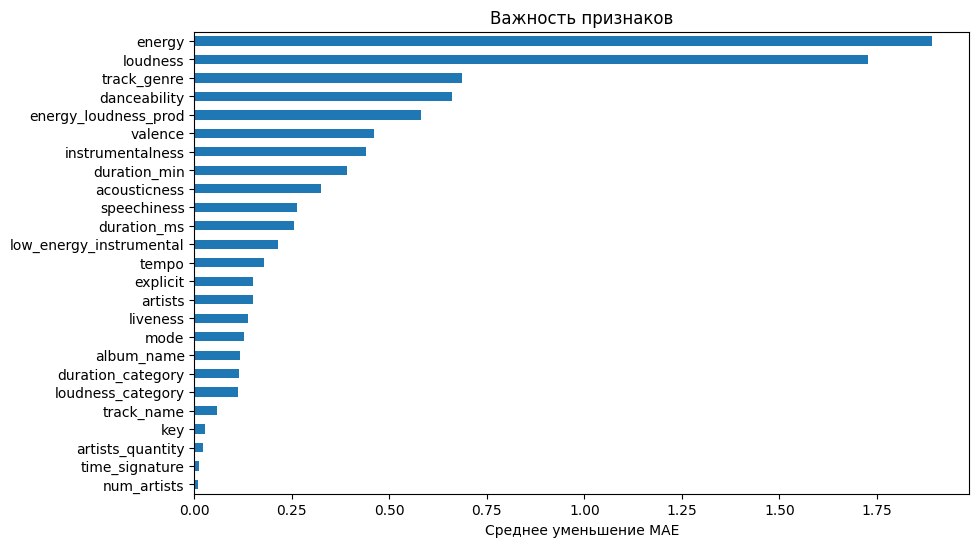

In [54]:
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
importances = pd.Series(result.importances_mean, index=X.columns)

importances.sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Важность признаков')
plt.xlabel('Среднее уменьшение MAE')
plt.show()

Permutation importance показал выдающуюся важность нового признака в снижении ошибки модели. В то же время признаки, начиная с time_signature и заканчивая artists_quantity, продемонстрировали крайне слабое влияние на результат. Поэтому я решил их удалить

In [55]:
new_norm_data = (normalized_data
          .drop(['time_signature',  
                 'key', 
                 'num_artists', 
                 'artists_quantity'], axis=1))
new_norm_data

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,loudness,mode,...,instrumentalness,liveness,valence,tempo,track_genre,duration_min,energy_loudness_prod,low_energy_instrumental,loudness_category,duration_category
0,9812,7916,11118,73,230666,0,0.676,0.4610,-6.746,0,...,0.000001,0.3580,0.7150,87.917,0,3.844433,-3.109906,0,4,2
1,3123,14527,21361,55,149610,0,0.420,0.1660,-17.235,1,...,0.000006,0.1010,0.2670,77.489,0,2.493500,-2.861010,1,3,2
2,11756,38516,57613,57,210826,0,0.438,0.3590,-9.734,1,...,0.000000,0.1170,0.1200,76.332,0,3.513767,-3.494506,0,4,2
3,14022,8388,9115,71,201933,0,0.266,0.0596,-18.515,1,...,0.000071,0.1320,0.1430,181.740,0,3.365550,-1.103494,1,3,2
4,4980,16589,24381,82,198853,0,0.618,0.4430,-9.681,1,...,0.000000,0.0829,0.1670,119.949,0,3.314217,-4.288683,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21307,65,50593,21,384999,0,0.172,0.2350,-16.393,1,...,0.928000,0.0863,0.0339,125.995,113,6.416650,-3.852355,1,3,3
113996,21307,65,61727,22,385000,0,0.174,0.1170,-18.318,0,...,0.976000,0.1050,0.0350,85.239,113,6.416667,-2.143206,1,3,3
113997,4697,4918,36212,22,271466,0,0.629,0.3290,-10.895,0,...,0.000000,0.0839,0.7430,132.378,113,4.524433,-3.584455,1,3,2
113998,17527,7090,20392,41,283893,0,0.587,0.5060,-10.889,1,...,0.000000,0.2700,0.4130,135.960,113,4.731550,-5.509834,1,3,2


Разделение данных на обучающую и тестовую выборки после удаления колонок

In [56]:
X = new_norm_data.drop(columns=['popularity'])
y = new_norm_data['popularity'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Эксперименты с моделями машинного обучения**

In [57]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = keras.Sequential([
    Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

loss = model.evaluate(X_test, y_test)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'Test Loss: {loss}')
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')

Epoch 1/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 542.8278 - val_loss: 339.5576
Epoch 2/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 330.1493 - val_loss: 329.7315
Epoch 3/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 320.4572 - val_loss: 321.8936
Epoch 4/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 314.7079 - val_loss: 318.5106
Epoch 5/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 310.6035 - val_loss: 314.2132
Epoch 6/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 303.8929 - val_loss: 313.3264
Epoch 7/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 305.8537 - val_loss: 312.3613
Epoch 8/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 307.0635 - val_loss: 311.9646
Epoch 9/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 302.3437 - val_loss: 310.0264
Epoch 10/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 299.4067 - val_loss: 309.0634
Epoch 11/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 299.6894 - val_l

После переобучения той же самой модели на датасете без удаленных колонок результат не изменился

Улучшим модель: углублю структуру с постепенным уменьшением количества нейронов. Для избежания переобучения буду использовать dropout. Количество эпох увеличу уже с прошлого шага увеличил до 20

In [58]:
# Масштабирование данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание модели
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1) 
])

# Компиляция модели
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Обучение модели
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Оценка модели
loss = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

print(f'Test Loss: {loss}')

Epoch 1/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 515.6243 - val_loss: 338.2679
Epoch 2/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 352.6561 - val_loss: 330.4710
Epoch 3/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 346.2462 - val_loss: 331.7512
Epoch 4/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 340.0633 - val_loss: 326.9679
Epoch 5/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 335.9449 - val_loss: 324.2105
Epoch 6/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 331.2057 - val_loss: 329.7160
Epoch 7/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 330.7640 - val_loss: 325.3388
Epoch 8/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 325.2123 - val_loss: 326.0665
Epoch 9/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 323.3079 - val_loss: 326.4025
Epoch 10/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 324.3600 - val_loss: 324.3662
Epoch 11/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 321.5670 - val_l

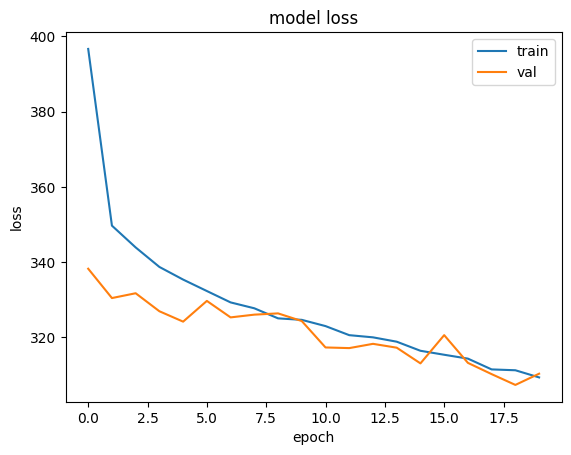

In [59]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt. xlabel ('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

На первой эпохе потери резко падают, а дальше более плавно уменьшаются по мере увеличения эпох. Линии для train и val достаточно близки друг к другу, особенно на последних эпохах, что говорит об отсутствии переобучения.

Попрубую еще углубить нейросеть одним слоем на 256 нейронов, для нормализации активации слоев буду использовать BatchNormalization. 

In [60]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = keras.Sequential([
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

loss = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

print(f'Test Loss: {loss}')

Epoch 1/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 584.0615 - val_loss: 339.3791
Epoch 2/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 369.9017 - val_loss: 328.6642
Epoch 3/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 354.9939 - val_loss: 317.3294
Epoch 4/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 345.5559 - val_loss: 329.2000
Epoch 5/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 337.5149 - val_loss: 338.8615
Epoch 6/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 333.8689 - val_loss: 314.0792
Epoch 7/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 323.7593 - val_loss: 305.0771
Epoch 8/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 321.5122 - val_loss: 333.3338
Epoch 9/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 317.6369 - val_loss: 333.3492
Epoch 10/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 317.4644 - val_loss: 333.6719
Epoch 11/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 315.4211 - val_

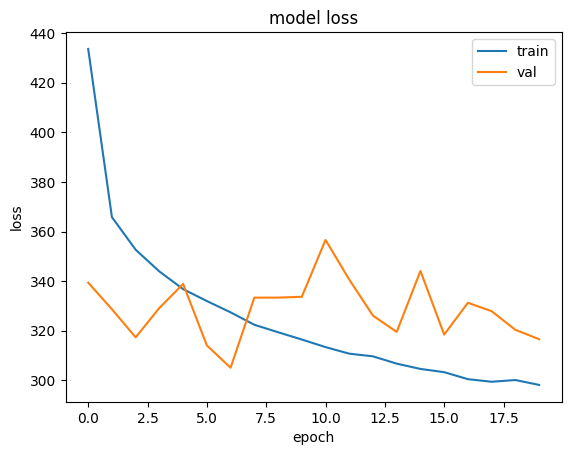

In [61]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt. xlabel ('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

Фиксирую небольшое падение loss с 246 до 236 обучающей выборки, а так же очень поломанный график валидационной выборки. Попробую увеличить количество эпох до 30. Во избежании переобучения воспользуюсь колбеком EarlyStopping, а для предотвращения застоя колбеком ReduceLROnPlateau, так как на последних эпохах все медленее и медленее снижаются потери

In [62]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import regularizers

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = keras.Sequential([
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# колбеки
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(X_train, y_train, epochs=30, batch_size=32, 
                    validation_split=0.2, callbacks=[early_stop, reduce_lr])

loss = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

print(f'Test Loss: {loss}')

Epoch 1/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 562.2965 - val_loss: 321.4957 - learning_rate: 0.0010
Epoch 2/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 335.7049 - val_loss: 316.4335 - learning_rate: 0.0010
Epoch 3/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 326.1946 - val_loss: 313.8043 - learning_rate: 0.0010
Epoch 4/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 319.8858 - val_loss: 311.4454 - learning_rate: 0.0010
Epoch 5/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 318.4223 - val_loss: 306.4052 - learning_rate: 0.0010
Epoch 6/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 315.2787 - val_loss: 303.8557 - learning_rate: 0.0010
Epoch 7/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 311.8886 - val_loss: 303.2524 - learning_rate: 0.0010
Epoch 8/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 308.1022 - val_loss: 302.5755 - learning_rate: 0.0010
Epoch 9/30
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 304.5734 -

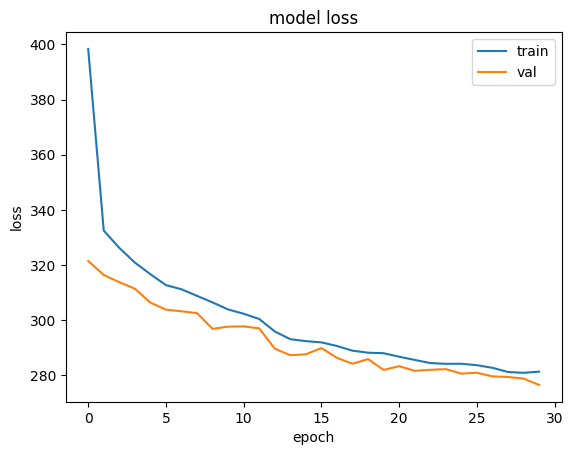

In [63]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt. xlabel ('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

Удалось еще немного понизить потери с 236 до 230. График показал стабильное обучение модели, а так же хорошую сходимость: линии ошибок на обучающей и валидационной выборках практически совпали. Остановлюсь на этой модели.

Вычесление метрик для сравнения с моделями из других семейств

In [64]:
from sklearn.metrics import r2_score

In [65]:
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, predictions)

print("--- Нейронная сеть ---")
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')
print(f"R2: {r2:.4f}")

613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- Нейронная сеть ---
MAE: 13.027268887247496
MSE: 280.89996452721556
RMSE: 16.760070540639607
MAPE: 1.4342716624136587
R2: 0.2473


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

In [67]:
# Функция для обучения и оценки моделей
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R2: {r2:.4f}")
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

**LinearRegression** - простая модель, которая находит оптимальные веса для признаков, минимизируя среднеквадратичную ошибку

In [68]:
linear_model = LinearRegression()

print("--- Линейная модель ---")
linear_results = train_and_evaluate(linear_model, X_train, X_test, y_train, y_test)

--- Линейная модель ---
MAE: 15.2319
MSE: 347.9774
RMSE: 18.6542
MAPE: 1.6929
R2: 0.0675


**RandomForestRegressor** - модель, использующая множество деревьев решений, где каждое дерево обучается на случайной подвыборке данных. Принцип работы: усредняет предсказания множества деревьев для уменьшения переобучения и улучшения точности.

In [69]:
tree_model = RandomForestRegressor(n_estimators=100, random_state=42)

print("\n--- Деревья решений ---")
tree_results = train_and_evaluate(tree_model, X_train, X_test, y_train, y_test)


--- Деревья решений ---
MAE: 9.4494
MSE: 163.7919
RMSE: 12.7981
MAPE: 0.9401
R2: 0.5611


**XGBRegressor** - модель, основанная на градиентном бустинге, которая строит деревья последовательно, минимизируя ошибку предыдущих шагов. Принцип работы: Улучшает предсказания путем добавления новых деревьев, фокусируясь на "трудных" примерах. Использует регуляризацию для предотвращения переобучения.

In [70]:
boosting_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

print("\n--- Градиентный бустинг ---")
boosting_results = train_and_evaluate(boosting_model, X_train, X_test, y_train, y_test)


--- Градиентный бустинг ---
MAE: 11.0093
MSE: 212.5735
RMSE: 14.5799
MAPE: 1.3313
R2: 0.4304


Лучшей моделью оказалась RandomForestRegressor с наибольшим коэфициентом детерминации R2 0.59. На втором месте располагается модель XGBRegressor из семейства градиентного бустинга с R2 0.47. Третье место получает самая долгоубучаемая модель - нейронная сеть с R2 0.38, а на последнем месте самая быстрообучаемая модель - линейной регрессии LinearRegression R2 0.29.

# **Кросс-валидация RandomForestRegressor**

In [71]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [72]:
# Функция для вычисления MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

tree_model = RandomForestRegressor(n_estimators=100, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Списки для хранения метрик
mae_list = []
mse_list = []
rmse_list = []
mape_list = []
r2_list = []

# Проход по фолдам
print("Метрики по фолдам")
for fold, (train_index, test_index) in enumerate(kf.split(X_train_np), 1):
    # Разделение данных
    X_fold_train, X_fold_test = X_train_np[train_index], X_train_np[test_index]
    y_fold_train, y_fold_test = y_train_np[train_index], y_train_np[test_index]
    
    # Обучение модели
    tree_model.fit(X_fold_train, y_fold_train)
    y_pred = tree_model.predict(X_fold_test)
    
    # Вычисление метрик
    mae = mean_absolute_error(y_fold_test, y_pred)
    mse = mean_squared_error(y_fold_test, y_pred)
    rmse = mean_squared_error(y_fold_test, y_pred, squared=False)
    mape = mean_absolute_percentage_error(y_fold_test, y_pred)
    r2 = r2_score(y_fold_test, y_pred)
    
    # Сохранение метрик
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    mape_list.append(mape)
    r2_list.append(r2)
    
    # Вывод метрик для текущего фолда
    print(f"Фолд {fold}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.4f}")
    print(f"  R2: {r2:.4f}")

# Средние метрики
print("\nСредние метрики по всем фолдам")
print(f"Средний MAE: {np.mean(mae_list):.4f}")
print(f"Средний MSE: {np.mean(mse_list):.4f}")
print(f"Средний RMSE: {np.mean(rmse_list):.4f}")
print(f"Средний MAPE: {np.mean(mape_list):.4f}")
print(f"Средний R2: {np.mean(r2_list):.4f}")

Метрики по фолдам
Фолд 1:
  MAE: 9.7416
  MSE: 172.9907
  RMSE: 13.1526
  MAPE: 99.2092
  R2: 0.5292
Фолд 2:
  MAE: 9.7392
  MSE: 171.6873
  RMSE: 13.1030
  MAPE: 97.3610
  R2: 0.5336
Фолд 3:
  MAE: 9.9478
  MSE: 180.3071
  RMSE: 13.4278
  MAPE: 104.4325
  R2: 0.5096
Фолд 4:
  MAE: 9.7644
  MSE: 176.4467
  RMSE: 13.2833
  MAPE: 102.5105
  R2: 0.5207
Фолд 5:
  MAE: 9.7738
  MSE: 176.4536
  RMSE: 13.2836
  MAPE: 99.7942
  R2: 0.5183

Средние метрики по всем фолдам
Средний MAE: 9.7934
Средний MSE: 175.5771
Средний RMSE: 13.2501
Средний MAPE: 100.6615
Средний R2: 0.5223


# **Вывод**

В ходе работы были исследованы данные о музыкальных треках на площадке Spotify с целью выявления и создания признаков, по которым модель машинного обучения сможет предсказывать популярность песен. Из исходных данных оказалось весьма трудно определить закономерности, которые позволят добиться поставленной цели. Были придуманы гипотезы, на основании наиболее успешных создавались новые признаки, которые продемонстрировали слабую эффективность в обучении модели.

На этих данных были обучены 4 модели машинного обучения: нейронная сеть keras, линейная LinearRegression, деревья RandomForestRegressor и модифицкации градиентного бустинга XGBRegressor. Лучше всего себя показала модель RandomForestRegressor, для которой была проведена кросс-валидация. По сравнению с самой первой моделью, кросс-валидация показала значительно улучшенные результаты.

Лучшей моделью оказалась RandomForestRegressor с наибольшим коэфициентом детерминации R2 0.59. На втором месте располагается модель XGBRegressor из семейства градиентного бустинга с R2 0.47. Третье место получает самая долгоубучаемая модель - нейронная сеть с R2 0.38, а на последнем месте самая быстрообучаемая модель - линейной регрессии LinearRegression R2 0.29.

Метрики: SequentialModel    LinearRegression   RandomForestRegressor XGBRegressor

MAE          13.0                 15.2                 9.4                 11.0

MSE          280.9                348.0                163.8               212.6

RMSE         16.8                 18.6                 12.8                14.6

MAPE         1.4                  1.7                  0.9                 1.3     

R2           0.25                 0.06                 0.57                0.43